In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import torch
import dnnlib.util_v4 as util
from tqdm import tqdm
import pickle
from matplotlib.ticker import FuncFormatter
import pickle, types
from torch_utils import persistence

from PIL import Image

import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from plot_neural import *
from plot_sim_results_v6 import *
from plot_sim_results_img_v6 import * 


import pandas as pd

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
colorgrad = "PuOr"

In [2]:
print(os.getcwd())

/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt


# 1. Read Data

In [306]:
folder_data = 'out/ball/t/data'
# folder = 'out/ball/test/00003-balls-prr-uncond-regularFM-gpus1-batch256-fp32'
# chk_pts = '/network-snapshot-100000.pkl' # '/network-snapshot-210739.pkl'

folder = 'out/ball/t/00004-balls-prr-uncond-regularFM-gpus1-batch256-fp32'
# folder = 'out/ball/test/softer_bad'
chk_pts = '/network-snapshot-035840.pkl' # '/network-snapshot-210739.pkl'




# network-snapshot-084992
pkl_path = folder + chk_pts

useCov = False

In [307]:
dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
cov_static_samples = np.load(folder_data + "/cov_static_trunc_only.npz", allow_pickle=True)
dset_samples = to_list_of_arrays(dataset_samples['samples'])
cov_stat_samples = to_list_of_arrays(cov_static_samples['samples'])

Just to see how large the noise I can use

In [308]:
# # no clamp
# clamp_range = None

# # version 1: global clamp (results are similar)
# eps = 1e-2
# min_value = min(np.min(arr) for arr in dset_samples)
# max_value = max(np.max(arr) for arr in dset_samples)
# clamp_range = np.array([min_value - eps, max_value + eps], dtype=np.float32) # give some space

# version 2: clamp dim-by-dim (results are similar)
eps = 1e-2
T_max = max(a.shape[0] for a in dset_samples)
padded = [np.pad(a, ((0, T_max-a.shape[0]), (0,0), (0,0), (0,0)), mode='constant', constant_values=np.nan)
          for a in dset_samples]                                              # -> (n_trial, T_max, C, H, W)
stacked = np.stack(padded, axis=0)
min_img = np.nanmin(stacked, axis=(0,1))                                      # shape (C,H,W)
max_img = np.nanmax(stacked, axis=(0,1))                                      # shape (C,H,W)
clamp_range = np.stack([min_img - eps, max_img + eps], axis=0).astype(np.float32)  # shape (2,C,H,W)

# 2. Read Model

In [309]:
# if not hasattr(persistence, "_orig_reconstruct"):
#     persistence._orig_reconstruct = persistence._reconstruct_persistent_obj
# def _tolerant_reconstruct(meta):
#     try:
#         return persistence._orig_reconstruct(meta)
#     except Exception:
#         class _Stub: pass
#         return _Stub()

# class PatchedUnpickler(pickle.Unpickler):
#     def find_class(self, module, name):
#         if module == "torch_utils.persistence" and name == "_reconstruct_persistent_obj":
#             return _tolerant_reconstruct
#         return super().find_class(module, name)

# with open(pkl_path, "rb") as f:
#     model_all = PatchedUnpickler(f).load()

# net = model_all["ema"] if "ema" in model_all else model_all["net"]
# flow_net = net.unet_model
# dyn_net   = net.vnet_model
# encoder   = net.encoder

with open(pkl_path, 'rb') as f:
    model_all = pickle.load(f)
if 'ema' in model_all: net = model_all['ema']  # EMA-stabilized model (recommended for inference/simulation)
else: net = model_all['net']  # Raw trained model
flow_net = net.unet_model  # Compressive flow (u_theta)
dyn_net = net.vnet_model   # Dynamics flow (v_theta)
encoder = net.encoder
lag = infer_lag_k_from_dyn_net(dyn_net)

In [310]:
if dyn_net.use_t_dyn: print('use t_dyn for dynamic flow')
else: print('no t_dyn for dynamic flow')

use t_dyn for dynamic flow


Let's plot the gradient of for each pixel

In [311]:
# plot_grad_frame(dset_samples, T=7, trial_idx=0, signed=True)

In [312]:
# plot_optical_flow_frames(dset_samples, T=7, trial_idx=0,
#                          r=2, lam=1e-3, stride=2,
#                          img_alpha=0.6, arrow_scale=2.0, arrow_width=0.01,
#                         show_image_bg = True)

In [313]:
# plot_optical_flow_frames(dset_samples, T=7, trial_idx=0,
#                          r=2, lam=1e-3, stride=2,
#                          img_alpha=0.6, arrow_scale=2.0, arrow_width=0.01,
#                         show_image_bg = False)

# 3. Simulate Trajectories

In [314]:
is_image = (np.asarray(dset_samples[0]).ndim == 4)
if is_image:
    _, C, H, W = np.asarray(dset_samples[0]).shape
T_min = min(arr.shape[0] for arr in dset_samples)
T_max = max(arr.shape[0] for arr in dset_samples)

In [315]:
n_step = T_max
clamp_range2 = None 

In [316]:
tau = 1.0
traj_sim_tau1_flattent, lag_cov_list = generate_traj_image_onthefly(dyn_net.to(device),
                                                                    dset_samples, n_step,
                                                                    tau, device, lag,
                                                                    include_x0_tau=False,
                                                                    oracle=False, lag_cov_list_pre=None,
                                                                    flow_net=None,
                                                                    clamp_range=clamp_range
                                                                    )

100%|█████████████████████████████████████████| 497/497 [00:25<00:00, 19.83it/s]


In [317]:
out_imgs_tau1 = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau1_flattent ]

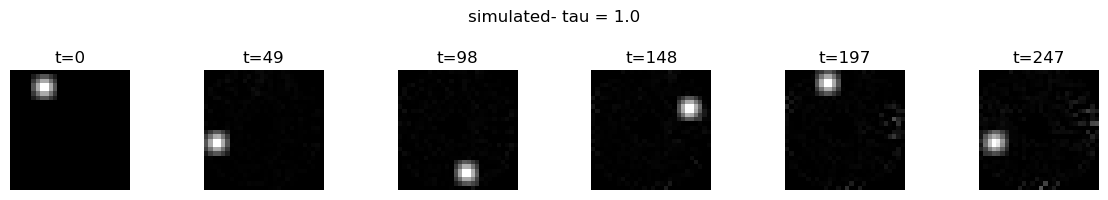

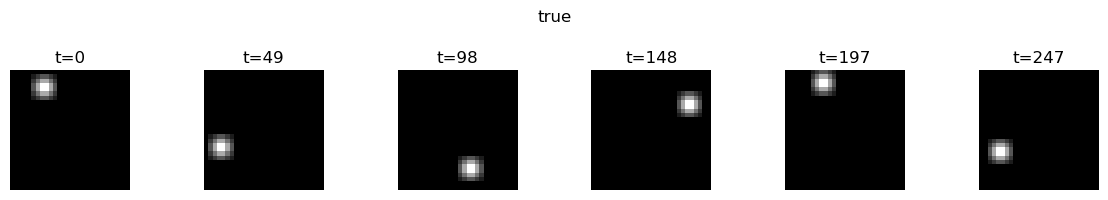

In [318]:
T = T_max//2
trial_idx = 0
plot_frame(out_imgs_tau1, T, trial_idx)
plt.suptitle('simulated- tau = 1.0')
plt.tight_layout()
plot_frame(dset_samples, T, trial_idx)
plt.suptitle('true')
plt.tight_layout()

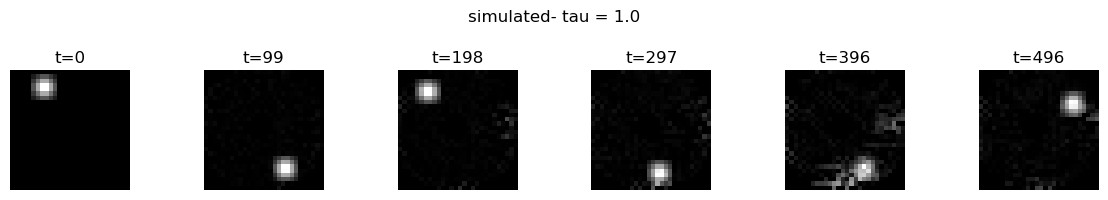

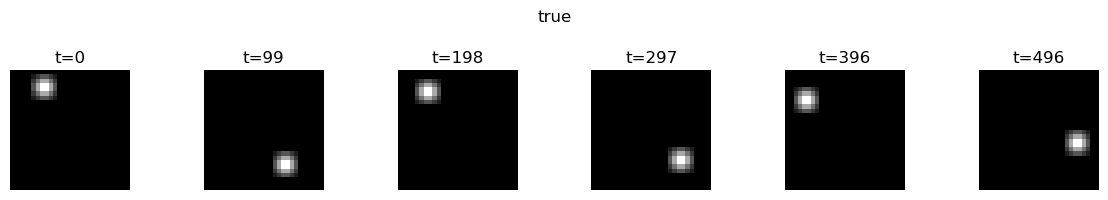

In [319]:
T = T_max
trial_idx = 0
plot_frame(out_imgs_tau1, T, trial_idx)
plt.suptitle('simulated- tau = 1.0')
plt.tight_layout()
plot_frame(dset_samples, T, trial_idx)
plt.suptitle('true')
plt.tight_layout()

In [320]:
tau = 0.0
traj_sim_tau0_flattent, _ = generate_traj_image_onthefly(dyn_net.to(device),
                                                         dset_samples, n_step,
                                                         tau, device, lag,
                                                         include_x0_tau=False,
                                                         oracle=False,
                                                         lag_cov_list_pre=lag_cov_list,
                                                         flow_net=flow_net.to(device),
                                                         clamp_range=clamp_range
                                                         )

100%|█████████████████████████████████████████| 497/497 [00:25<00:00, 19.44it/s]


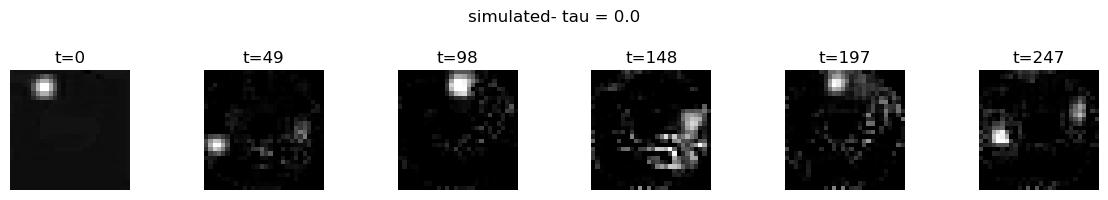

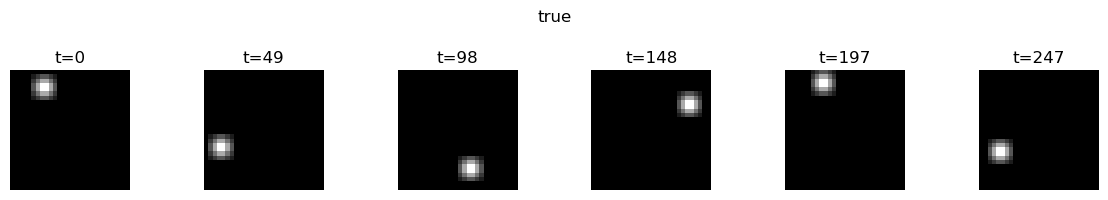

In [321]:
out_imgs_tau0 = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau0_flattent ]
plot_frame(out_imgs_tau0, T_max//2, trial_idx)
plt.suptitle('simulated- tau = 0.0')
plt.tight_layout()
plot_frame(dset_samples, T_max//2, trial_idx)
plt.suptitle('true')
plt.tight_layout()

# 4. Plot Latent

## 4.1 simulated

In [322]:
dim_to_keep = 2
mu_traj_sim, d, L, loading = latent_mu(traj_sim_tau0_flattent, encoder.to(device),
                                       dim_to_keep, device, fullRes = True,
                                      min_var=1e-10, rcond=1e-20)

In [323]:
d[0:10]

tensor([5.8078e-01, 5.4240e-01, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05,
        1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05], device='cuda:0')

In [324]:
dim_to_keep = 2
mu_traj_sim, d, L, loading = latent_mu(traj_sim_tau0_flattent, encoder.to(device),
                                       dim_to_keep, device, fullRes = True,
                                      min_var=1e-10, rcond=1e-20)
# idx_show = 100 # L.shape[1]
# L[0:idx_show,0:idx_show]

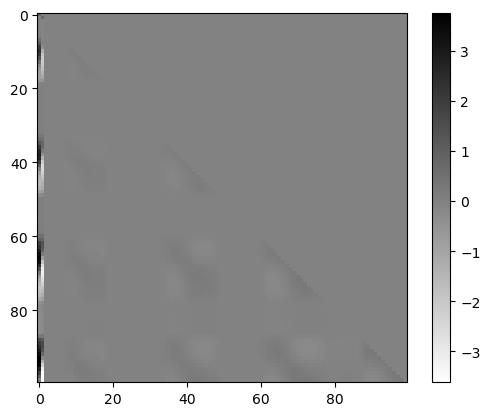

In [325]:
idx_show = 100
plt.imshow(loading[0:idx_show,0:idx_show].detach().cpu().numpy(), cmap = 'gray_r')
plt.colorbar()

Text(0.5, 0.98, 'simulated latent trajc for each trial')

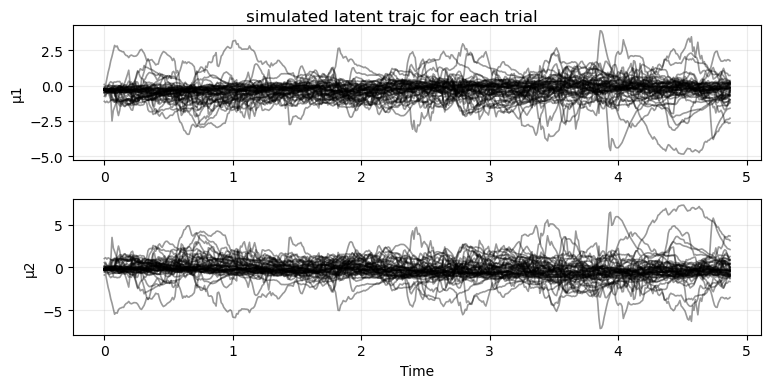

In [326]:
mu_traj_sim_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]
mu_traj_sim_np_plot = [mu_traj_sim_np[ii][10:,:] for ii in range(len(mu_traj_sim_np))]
plot_latent_time_series(mu_traj_sim_np_plot, alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)
plt.suptitle('simulated latent trajc for each trial')

## 4.2 flowed

In [327]:
latent_traj_list = proj_to_latent(dset_samples, flow_net.to(device), 0.0, device)
mu_traj_sim, d, L, loading = latent_mu(latent_traj_list, encoder.to(device), dim_to_keep, device, fullRes = True,
                                      min_var=1e-10, rcond=1e-20)

Text(0.5, 0.98, 'flowed latent trajc for each trial')

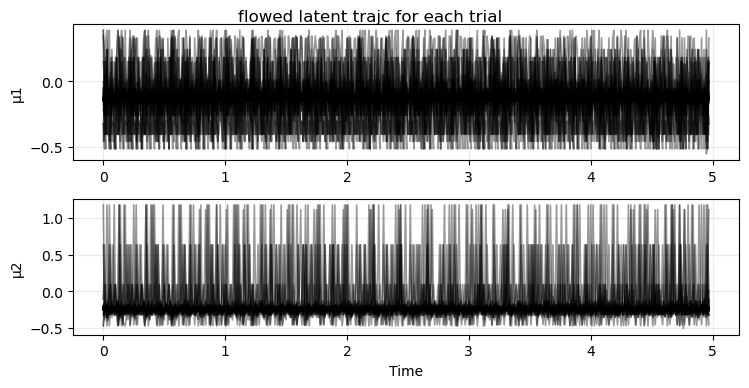

In [328]:
mu_traj_sim_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]
plot_latent_time_series(mu_traj_sim_np, alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)
plt.suptitle('flowed latent trajc for each trial')